# Gulf - Matchup Analysis #

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.stats as stats

In [11]:
os.getcwd()

'/home/jovyan/2026-proj-hypoxia-zones/contributor_folders/stormheidinger'

In [12]:
matchup_df = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")

In [13]:
matchup_df

,SHIP,CRUISE,STATION,DATE,longitude,latitude,oxygen,LEG,TIME,CAST,...,PRrs708,PRrs709,PRrs711,PRrs712,PRrs713,PRrs714,PRrs717,PRrs719,pad,unID
0,OREGON II,352,1,2024-06-04 00:00:00,-89.996833,28.501333,4.0673,1,18:20:56,1,...,0.000015,0.000010,0.000025,0.000020,-0.000011,-0.000029,0.000016,0.000164,_,352_1_20240603T175658
1,OREGON II,352,1,2024-06-04 00:00:00,-89.996833,28.501333,4.0673,1,18:20:56,1,...,0.000000,-0.000016,-0.000008,-0.000008,-0.000014,-0.000032,-0.000040,0.000004,_,352_1_20240603T180158
2,OREGON II,352,1,2024-06-04 00:00:00,-89.996833,28.501333,4.0673,1,18:20:56,1,...,-0.000096,-0.000102,-0.000108,-0.000118,-0.000134,-0.000122,-0.000004,0.000208,_,352_1_20240605T173312
3,OREGON II,352,1,2024-06-04 00:00:00,-89.996833,28.501333,4.0673,1,18:20:56,1,...,0.000088,0.000088,0.000104,0.000096,0.000090,0.000070,0.000074,0.000118,_,352_1_20240605T190632
4,OREGON II,352,2,2024-06-04 00:00:00,-90.121500,28.363000,4.4879,1,21:53:52,1,...,0.000088,0.000070,0.000070,0.000058,0.000000,-0.000020,0.000062,0.000332,_,352_2_20240603T175658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,OREGON II,356,191,2025-07-13 00:00:00,-83.872667,27.456667,6.8365,3,14:27:45,1,...,-0.000274,-0.000292,-0.000300,-0.000290,-0.000300,-0.000244,0.000318,0.000888,_,356_191_20250714T191712
849,OREGON II,356,192,2025-07-13 00:00:00,-83.833167,27.575667,6.9689,3,21:04:23,1,...,-0.000092,-0.000078,-0.000048,-0.000054,-0.000064,-0.000096,-0.000154,-0.000234,_,356_192_20250713T184702
850,OREGON II,356,192,2025-07-13 00:00:00,-83.833167,27.575667,6.9689,3,21:04:23,1,...,-0.000102,-0.000118,-0.000126,-0.000118,-0.000118,-0.000036,0.000586,0.001128,_,356_192_20250714T191712
851,OREGON II,356,193,2025-07-13 00:00:00,-83.760500,27.642500,7.1273,3,22:47:34,1,...,0.000308,0.000298,0.000278,0.000260,0.000239,0.000214,0.000224,0.000335,_,356_193_20250712T180652


In [14]:
rrs_col = matchup_df.columns[18:189]
rrs_col

Index(['PRrs348', 'PRrs351', 'PRrs353', 'PRrs356', 'PRrs358', 'PRrs361',
       'PRrs363', 'PRrs366', 'PRrs368', 'PRrs371',
       ...
       'PRrs706', 'PRrs707', 'PRrs708', 'PRrs709', 'PRrs711', 'PRrs712',
       'PRrs713', 'PRrs714', 'PRrs717', 'PRrs719'],
      dtype='object', length=171)

In [42]:
hypoxic_threshold = 3
matchup_df_hypoxic = matchup_df[matchup_df['oxygen']<=hypoxic_threshold]
matchup_df_oxic = matchup_df[matchup_df['oxygen']>hypoxic_threshold]

In [35]:
def plot_rrs_validation(df,rrs_col_name,var_name,plot_name):

    x=df[rrs_col_name]
    y=df[var_name]

    result = stats.linregress(x, y)
    
    new_row = {'PRrs_wv': rrs_col_name, 
               'Slope':result.slope,
               'Intercept': result.intercept,
               'Pearson_Corr': result.rvalue,
               'P_value': result.pvalue,
               'StdErr': result.stderr}

    y_hat = x*result.slope + result.intercept
    
    fig, ax = plt.subplots()
    ax.scatter(x,y,label='Matchup Points',color='tab:blue')
    ax.plot(x,y_hat,label='Linear Regression',color='tab:red')
    ax.set_xlabel(rrs_col_name)
    ax.set_ylabel(var_name)
    ax.set_title(plot_name)
    ax.legend(loc='best')
    fig.savefig(f'./matchup_plots/by_wavelength/{plot_name}_{rrs_col_name}_{var_name}.png')
    plt.close()

    return new_row

In [51]:
rows_list = []

In [52]:
for r in rrs_col:
    rows_list.append(plot_rrs_validation(matchup_df_oxic,
                                         r,
                                         'oxygen',
                                         'NOAA - Oxic'))

In [53]:
validation_stats_df = pd.DataFrame(rows_list)

In [54]:
validation_stats_df['wv'] = validation_stats_df['PRrs_wv'].str[4:]
validation_stats_df['wv'] = pd.to_numeric(validation_stats_df['wv'])

In [55]:
validation_stats_df.head()

,PRrs_wv,Slope,Intercept,Pearson_Corr,P_value,StdErr,wv
0,PRrs348,32.965123,5.152121,0.170160,1.217321e-06,6.741082,348
1,PRrs351,35.566508,5.135182,0.181355,2.251354e-07,6.810247,351
2,PRrs353,38.425820,5.120162,0.193798,3.039336e-08,6.868708,353
3,PRrs356,41.230955,5.099732,0.206791,3.248775e-09,6.888331,356
4,PRrs358,43.348283,5.074724,0.217102,4.950760e-10,6.882366,358


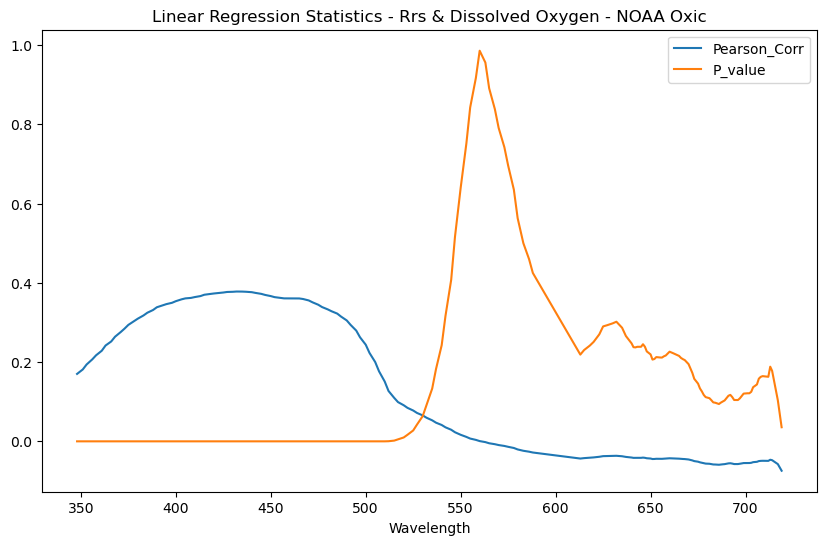

In [56]:
v_fig, v_ax = plt.subplots(figsize=(10,6))
v_ax.plot(validation_stats_df['wv'],validation_stats_df['Pearson_Corr'],label='Pearson_Corr')
v_ax.plot(validation_stats_df['wv'],validation_stats_df['P_value'],label='P_value')
v_ax.set_xlabel('Wavelength')
v_ax.set_title('Linear Regression Statistics - Rrs & Dissolved Oxygen - NOAA Oxic')
v_ax.legend(loc='best')
v_fig.savefig(f'./matchup_plots/validation_stats/NOAA_Oxic.png')
plt.show()
plt.close()